# Tasks 4.3 and 4.9

## Task 4.3

**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for Vic B/Austria/1359417/2021 at Day 28 post-vaccination.

## Task 4.9

**4.9 Predict antibody durability - Vic B/Austria/1359417/2021 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Post-vac HAI
* Metric: Spearman correlation
* Full description: Post-vac HAI of the B Victoria vaccine strain at Day 365

Durability refers to how well the antibody response is maintained over time after vaccination.
We are predicting the post-vaccination HAI titer for Vic B/Austria/1359417/2021 at Day 365 post-vaccination.

## NOTE: y-values are log-2 transformed, however, since we are using Spearman the ordering is what matters and there is no need to reverse this transformation

In [1]:
TARGET_COL_4_3 = 'HAI_Vic B/Austria/1359417/2021_d28'  # task 4.3
TARGET_COL_4_9 = 'HAI_Vic B/Austria/1359417/2021_d365'  # task 4.9

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = 'cleaned_data'
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')
tables = {
    'train_hai': train_hai,
    'train_participants': train_participants
}

In [4]:
for name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_hai


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,...,HAI_Yam B/Sichuan/379/1999_d365,HAI_Yam B/Texas/6/2011_d0,HAI_Yam B/Texas/6/2011_d28,HAI_Yam B/Texas/6/2011_d365,HAI_Yam B/Wisconsin/1/2010_d0,HAI_Yam B/Wisconsin/1/2010_d28,HAI_Yam B/Wisconsin/1/2010_d365,HAI_Yam B/Yamagata/16/1988_d0,HAI_Yam B/Yamagata/16/1988_d28,HAI_Yam B/Yamagata/16/1988_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,...,NaN,7.321928,8.321928,NaN,8.321928,8.321928,NaN,7.321928,8.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,NaN,5.321928,6.321928,NaN,6.321928,6.321928,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,NaN,8.321928,8.321928,NaN,8.321928,8.321928,NaN,8.321928,8.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,...,NaN,4.321928,6.321928,NaN,5.321928,6.321928,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,...,6.321928,6.321928,6.321928,5.321928,6.321928,6.321928,5.321928,5.321928,5.321928,5.321928



TABLE: train_participants


,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,SDY269.SUB112836,Female,White,Georgia,Other,28.0
1,SDY269.SUB112849,Female,Black,Georgia,Other,39.0
2,SDY269.SUB112854,Male,Black,Georgia,Other,46.0
3,SDY269.SUB112860,Female,White,Georgia,Other,32.0
4,SDY269.SUB112881,Female,Black,Georgia,Other,29.0


### Data is pre-cleaned
Both tables are already one row per participant with cleaned column names:
- HAI columns follow `HAI_{strain}_d{timepoint}` format
- Participant columns follow `PART_{field}` format

We just need to merge them and separate features from target.

In [5]:
# Merge HAI and participant tables
data = train_hai.merge(train_participants, on='participant_id', how='inner')
print(f'Merged shape: {data.shape}')
data.head()

Merged shape: (3757, 201)


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,...,HAI_Yam B/Wisconsin/1/2010_d28,HAI_Yam B/Wisconsin/1/2010_d365,HAI_Yam B/Yamagata/16/1988_d0,HAI_Yam B/Yamagata/16/1988_d28,HAI_Yam B/Yamagata/16/1988_d365,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,...,8.321928,NaN,7.321928,8.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,6.321928,NaN,5.321928,5.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,8.321928,NaN,8.321928,8.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,28.0
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,...,6.321928,NaN,3.321928,5.321928,NaN,Male,Unknown,Georgia,Standard Fluzone,27.0
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,...,6.321928,5.321928,5.321928,5.321928,5.321928,Female,Unknown,Georgia,Standard Fluzone,25.0


In [6]:
STRAIN = 'Vic B/Austria/1359417/2021'
STRAIN_PREFIX = f'HAI_{STRAIN}'

# Task 4.3: strain-specific day 0 + day 7 columns + demographics (no future data)
part_cols = [c for c in data.columns if c.startswith('PART_')]
feature_cols = [
                   c for c in data.columns
                   if c.startswith(STRAIN_PREFIX) and (c.endswith('_d0') or c.endswith('_d7'))
               ] + part_cols

print(f'Target: {TARGET_COL_4_3}')
print(f'Features: {len(feature_cols)}')
print(f'Feature names: {feature_cols}')

Target: HAI_Vic B/Austria/1359417/2021_d28
Features: 6
Feature names: ['HAI_Vic B/Austria/1359417/2021_d0', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name', 'PART_age']


### Build X and y

In [7]:
# Target: single strain HAI titer at Day 28
y_vals = data[TARGET_COL_4_3].copy()

# Drop rows where target is NaN
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

# y-values already log-transformed, so no need to log2 them

print(f'Samples: {len(X)}')
print(f'Features: {X.shape[1]}')

Samples: 920
Features: 6


### Encode categorical features

In [8]:
# One-hot encode any categorical PART_ columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Encoding categorical columns: {cat_cols}')
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Final feature count: {X.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 4


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_16494/398821456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [9]:
X.head()

,HAI_Vic B/Austria/1359417/2021_d0,PART_age,PART_biological_sex_Male,PART_arm_name_Standard Fluzone
809,2.321928,32.0,False,True
810,2.321928,28.0,False,True
811,2.321928,50.0,False,True
812,2.321928,29.0,False,True
813,2.321928,65.0,False,False


### Train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [10]:
# Simple pipeline: impute remaining NaNs, then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f'Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})')

Spearman (5-fold CV): 0.671  (p-value: 0.0000)


### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

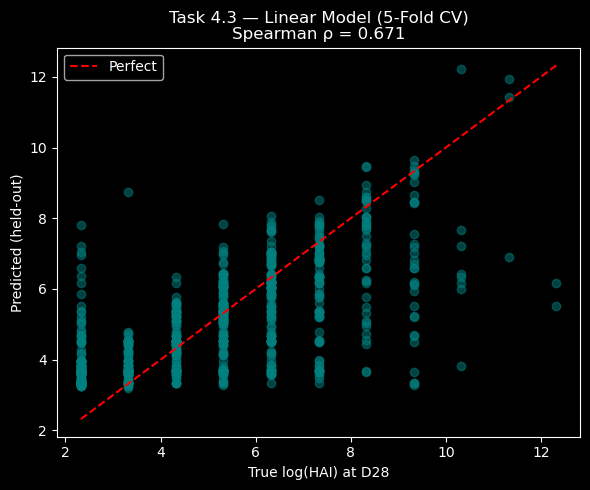

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.3 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
results = pd.DataFrame({
    'participant_id': data.loc[mask, 'participant_id'].values,
    'Task_4.3': np.expm1(y_pred_cv),  # reverse the log1p transform
})
results

,participant_id,Task_4.3
0,2020_UGA.ID_001,40.211389
1,2020_UGA.ID_005,38.132892
2,2020_UGA.ID_008,39.222138
3,2020_UGA.ID_011,40.242991
4,2020_UGA.ID_014,46.011600
...,...,...
915,2023_UGA.ID_750,36.356880
916,2023_UGA.ID_751,29.618902
917,2023_UGA.ID_753,214.756722
918,2023_UGA.ID_754,215.459979


In [13]:
rmse = np.sqrt(mean_squared_error(y_vals, y_pred_cv))
mse = mean_squared_error(y_vals, y_pred_cv)
mae = mean_absolute_error(y_vals, y_pred_cv)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_vals), np.log1p(y_pred_cv)))

print(f"{'Model':<40} {'RMSE':>8} {'MSE':>10} {'MAE':>8} {'RMSLE':>8} {'Spearman':>10}")
print(f"{'Linear Regression (5-Fold CV)':<40} {rmse:>8.4f} {mse:>10.4f} {mae:>8.4f} {rmsle:>8.4f} {rho_cv:>10.4f}")

Model                                        RMSE        MSE      MAE    RMSLE   Spearman
Linear Regression (5-Fold CV)              1.5617     2.4389   1.1617   0.2724     0.6710


In [14]:
# output to csv
results.to_csv('submission/task_4_3.csv', index=False)

---

## Task 4.9 — Predict Antibody Durability (D365)

Target: `HAI_Vic B/Austria/1359417/2021_d365`

Training features: demographics + the same strain's **Day 0**, **Day 7**, and **Day 28** titers.
Day 28 is included here (unlike 4.3) because the durability question is asking how well the
response holds from the D28 peak through to D365 — so D28 is prior information, not a future
label we're trying to predict.

In [15]:
# Task 4.9: strain-specific day 0, day 7, and day 28 + demographics
feature_cols_4_9 = [
                       c for c in data.columns
                       if c.startswith(STRAIN_PREFIX) and (c.endswith('_d0') or c.endswith('_d7') or c.endswith('_d28'))
                   ] + part_cols

y_vals_4_9 = data[TARGET_COL_4_9].copy()
mask_4_9 = y_vals_4_9.notna()
y_vals_4_9 = y_vals_4_9[mask_4_9]
X_4_9 = data.loc[mask_4_9, feature_cols_4_9].copy()

print(f'Target: {TARGET_COL_4_9}')
print(f'Features: {len(feature_cols_4_9)}')
print(f'Feature names: {feature_cols_4_9}')
print(f'Samples: {len(X_4_9)}')

Target: HAI_Vic B/Austria/1359417/2021_d365
Features: 7
Feature names: ['HAI_Vic B/Austria/1359417/2021_d0', 'HAI_Vic B/Austria/1359417/2021_d28', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name', 'PART_age']
Samples: 492


In [16]:
# One-hot encode categorical PART_ columns
cat_cols_4_9 = X_4_9.select_dtypes(include='object').columns.tolist()
if cat_cols_4_9:
    print(f'Encoding categorical columns: {cat_cols_4_9}')
    X_4_9 = pd.get_dummies(X_4_9, columns=cat_cols_4_9, drop_first=True)
print(f'Final feature count: {X_4_9.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 5


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_16494/3637414264.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_4_9 = X_4_9.select_dtypes(include='object').columns.tolist()


In [17]:
model_4_9 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv_4_9 = cross_val_predict(model_4_9, X_4_9, y_vals_4_9, cv=cv)
rho_cv_4_9, pval_cv_4_9 = spearmanr(y_vals_4_9, y_pred_cv_4_9)
print(f'Spearman (5-fold CV): {rho_cv_4_9:.3f}  (p-value: {pval_cv_4_9:.4f})')

Spearman (5-fold CV): 0.755  (p-value: 0.0000)


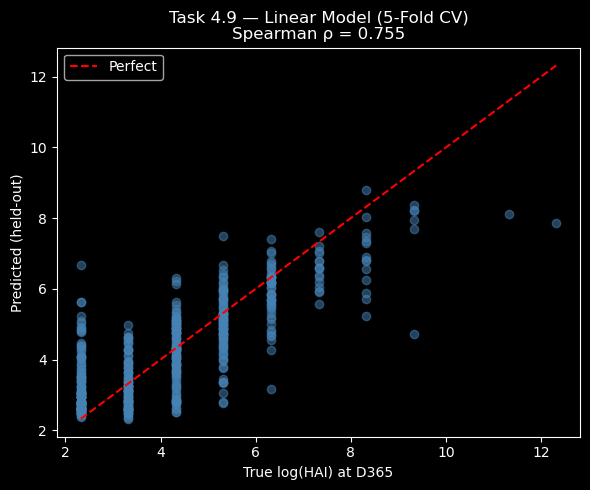

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals_4_9, y_pred_cv_4_9, alpha=0.5, color='steelblue')
plt.plot([y_vals_4_9.min(), y_vals_4_9.max()], [y_vals_4_9.min(), y_vals_4_9.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D365')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.9 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv_4_9:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
rmse_4_9 = np.sqrt(mean_squared_error(y_vals_4_9, y_pred_cv_4_9))
mse_4_9 = mean_squared_error(y_vals_4_9, y_pred_cv_4_9)
mae_4_9 = mean_absolute_error(y_vals_4_9, y_pred_cv_4_9)
rmsle_4_9 = np.sqrt(mean_squared_error(np.log1p(y_vals_4_9), np.log1p(y_pred_cv_4_9)))

print(f"{'Model':<40} {'RMSE':>8} {'MSE':>10} {'MAE':>8} {'RMSLE':>8} {'Spearman':>10}")
print(
    f"{'Linear Regression (5-Fold CV)':<40} {rmse_4_9:>8.4f} {mse_4_9:>10.4f} {mae_4_9:>8.4f} {rmsle_4_9:>8.4f} {rho_cv_4_9:>10.4f}")

Model                                        RMSE        MSE      MAE    RMSLE   Spearman
Linear Regression (5-Fold CV)              1.0499     1.1023   0.7886   0.2054     0.7552


In [20]:
results_4_9 = pd.DataFrame({
    'participant_id': data.loc[mask_4_9, 'participant_id'].values,
    'Task_4.9': np.expm1(y_pred_cv_4_9),
})
results_4_9.to_csv('submission/task_4_9.csv', index=False)
results_4_9

,participant_id,Task_4.9
0,2020_UGA.ID_001,12.592378
1,2020_UGA.ID_005,11.140415
2,2020_UGA.ID_008,12.681314
3,2020_UGA.ID_011,9.902660
4,2020_UGA.ID_014,15.024231
...,...,...
487,2022_UGA.ID_652,22.724261
488,2022_UGA.ID_653,264.421165
489,2022_UGA.ID_654,113.673233
490,2022_UGA.ID_717,279.084386
